In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd
import random
import nltk
from nltk.corpus import wordnet
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
df_small = pd.read_csv(
    'WELFake_original_small_2.csv',
    encoding='utf-8',
    on_bad_lines='skip',
    engine='python'
)

In [ ]:
from transformers import MarianMTModel, MarianTokenizer

In [ ]:
import torch
from tqdm import tqdm

In [ ]:


device = "cuda" if torch.cuda.is_available() else "cpu"

# EN → DE
model_name_en_de = "Helsinki-NLP/opus-mt-en-de"
tokenizer_en_de = MarianTokenizer.from_pretrained(model_name_en_de)
model_en_de = MarianMTModel.from_pretrained(model_name_en_de).to(device)

# DE → EN
model_name_de_en = "Helsinki-NLP/opus-mt-de-en"
tokenizer_de_en = MarianTokenizer.from_pretrained(model_name_de_en)
model_de_en = MarianMTModel.from_pretrained(model_name_de_en).to(device)


def translate_batch(texts, model, tokenizer, batch_size=16, desc="Translating"):
    results = []

    for i in tqdm(range(0, len(texts), batch_size), desc=desc):
        batch = texts[i:i+batch_size]

        inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True).to(device)

        with torch.no_grad():
            translated = model.generate(**inputs)

        decoded = tokenizer.batch_decode(translated, skip_special_tokens=True)
        results.extend(decoded)

    return results


def back_translation_batch(texts, batch_size=16):
    german = translate_batch(texts, model_en_de, tokenizer_en_de, batch_size, desc="EN → DE")
    back_translated = translate_batch(german, model_de_en, tokenizer_de_en, batch_size, desc="DE → EN")
    return back_translated

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/768k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/797k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/298M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/298M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

In [ ]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO GPU")

True
Tesla T4


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

nb_scores = {"acc": [], "prec": [], "rec": [], "f1": []}
lr_scores = {"acc": [], "prec": [], "rec": [], "f1": []}

for fold, (train_idx, test_idx) in enumerate(kf.split(df_small, df_small['label'])):
    print(f"\nFold {fold+1}")
    random.seed(42 + fold)

    train_df = df_small.iloc[train_idx].copy()
    test_df = df_small.iloc[test_idx].copy()


    # AUGMENTÁCIA LEN TRAIN
    sample_size = int(1 * len(train_df))

    aug_df = train_df.sample(sample_size, replace=True, random_state=42).copy()

    # batch back-translation
    texts = aug_df['text'].tolist()
    aug_texts = back_translation_batch(texts, batch_size=16)

    aug_df['text'] = aug_texts

    train_aug = pd.concat([train_df, aug_df])

    # TF-IDF
    vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

    X_train = vectorizer.fit_transform(train_aug['text'])
    y_train = train_aug['label'].astype(int)

    X_test = vectorizer.transform(test_df['text'])
    y_test = test_df['label'].astype(int)

    # MODELY
    nb = MultinomialNB()
    lr = LogisticRegression(max_iter=1000)

    nb.fit(X_train, y_train)
    lr.fit(X_train, y_train)

    y_pred_nb = nb.predict(X_test)
    y_pred_lr = lr.predict(X_test)

    # METRIKY
    def compute_metrics(y_true, y_pred):
        return {
            "acc": accuracy_score(y_true, y_pred),
            "prec": precision_score(y_true, y_pred, average='weighted', zero_division=0),
            "rec": recall_score(y_true, y_pred, average='weighted', zero_division=0),
            "f1": f1_score(y_true, y_pred, average='weighted', zero_division=0),
        }

    nb_m = compute_metrics(y_test, y_pred_nb)
    lr_m = compute_metrics(y_test, y_pred_lr)

    for k in nb_scores:
        nb_scores[k].append(nb_m[k])
        lr_scores[k].append(lr_m[k])

# VÝSLEDKY
print("\nNaive Bayes:")
for k in nb_scores:
    print(f"{k.upper()}: {nb_scores[k]}")
    print(f"Average {k.upper()}: {np.mean(nb_scores[k])}")

print("\nLogistic Regression:")
for k in lr_scores:
    print(f"{k.upper()}: {lr_scores[k]}")
    print(f"Average {k.upper()}: {np.mean(lr_scores[k])}")


Fold 1


DE → EN: 100%|██████████| 50/50 [16:10<00:00, 19.41s/it]



Fold 2


DE → EN: 100%|██████████| 50/50 [15:43<00:00, 18.88s/it]



Fold 3


...


Fold 4


DE → EN: 100%|██████████| 50/50 [16:11<00:00, 19.43s/it]



Fold 5


DE → EN: 100%|██████████| 50/50 [15:42<00:00, 18.85s/it]



Naive Bayes:
ACC: [0.78, 0.83, 0.82, 0.825, 0.82]
Average ACC: 0.8150000000000001
PREC: [0.7801120448179272, 0.8305288461538461, 0.8201280512204883, 0.8266003416742036, 0.8232323232323233]
Average PREC: 0.8161203214197578
REC: [0.78, 0.83, 0.82, 0.825, 0.82]
Average REC: 0.8150000000000001
F1: [0.77997799779978, 0.8299319727891157, 0.8199819981998201, 0.8247853620685339, 0.8195488721804511]
Average F1: 0.8148452406075404

Logistic Regression:
ACC: [0.855, 0.84, 0.805, 0.87, 0.85]
Average ACC: 0.844
PREC: [0.855035503550355, 0.8412284223203532, 0.8050305030503051, 0.8723832528180354, 0.8505608974358975]
Average PREC: 0.8448477158349892
REC: [0.855, 0.84, 0.805, 0.87, 0.85]
Average REC: 0.844
F1: [0.8549963749093727, 0.8398558702832548, 0.804995124878122, 0.8697916666666667, 0.8499399759903962]
Average F1: 0.8439158025455624


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

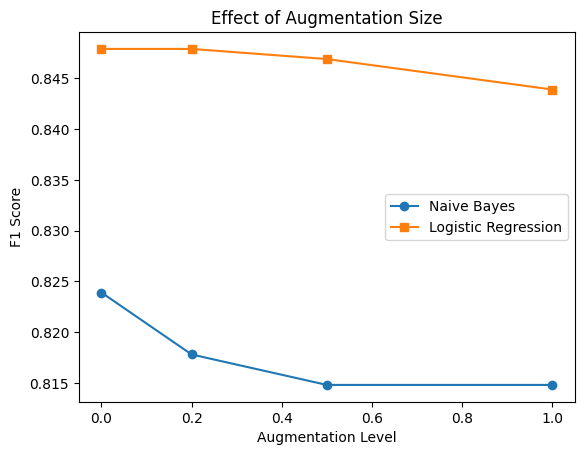

In [ ]:
sample_sizes = [0, 0.2, 0.5, 1]

# Naive Bayes
f1_scores_nb = [0.8239, 0.8178, 0.8148, 0.8148]

# Logistic Regression
f1_scores_lr = [0.8479, 0.8479,0.8469, 0.8439]

plt.figure()

plt.plot(sample_sizes, f1_scores_nb, marker='o', label='Naive Bayes')
plt.plot(sample_sizes, f1_scores_lr, marker='s', label='Logistic Regression')

plt.title("Effect of Augmentation Size")
plt.xlabel("Augmentation Level")
plt.ylabel("F1 Score")
plt.legend()  # zobrazí legendu

plt.show()